<a href="https://colab.research.google.com/github/fa623/ml-code/blob/main/Heart_Attack_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset Path

In [ ]:
import kagglehub
path = kagglehub.dataset_download("fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid")
import os
path_df=os.path.join(path,"Medicaldataset.csv")
df=pd.read_csv(path_df)

100%|██████████| 15.9k/15.9k [00:00<00:00, 15.3MB/s]

Extracting files...


In [ ]:
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


# Data Selection

In [ ]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
df.tail()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive
1318,51,1,94,157,79,134.0,50.89,1.770,positive


In [ ]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [ ]:
df.shape

(1319, 9)

# Replacing null values

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


# Data Conversion

In [ ]:
df["Result"]=df["Result"].astype("category")
df["Result"]=df["Result"].cat.codes

In [ ]:
df['Result']

,Result
0,0
1,1
2,0
3,1
4,0
...,...
1314,0
1315,1
1316,1
1317,1


In [ ]:
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


# Seperating and Lable

In [ ]:
x=df.drop(columns='Result',axis=1)
y=df['Result']

In [ ]:
x

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003
...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006
1315,66,1,84,125,55,149.0,1.33,0.172
1316,45,1,85,168,104,96.0,1.24,4.250
1317,54,1,58,117,68,443.0,5.80,0.359


In [ ]:
y

,Result
0,0
1,1
2,0
3,1
4,0
...,...
1314,0
1315,1
1316,1
1317,1


# preprocessing and standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


In [ ]:
sc.fit(x)

StandardScaler()

# Train Test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

# Training the model

# logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.7689393939393939

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

In [ ]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6590909090909091

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.9772727272727273

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [ ]:
model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.9848484848484849

# XGboost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(max_depth=1)

In [ ]:
model.fit(x_train,y_train)

GradientBoostingClassifier(max_depth=1)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1],
      dtype=int8)

In [ ]:
accuracy_score(y_test,y_pred)

0.9848484848484849

After setting `max_depth=1` for the `GradientBoostingClassifier`, let's re-train the model and check the accuracies again to see the impact of this change.

# Matplotlib and Seaborn

# line plot

In [ ]:
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


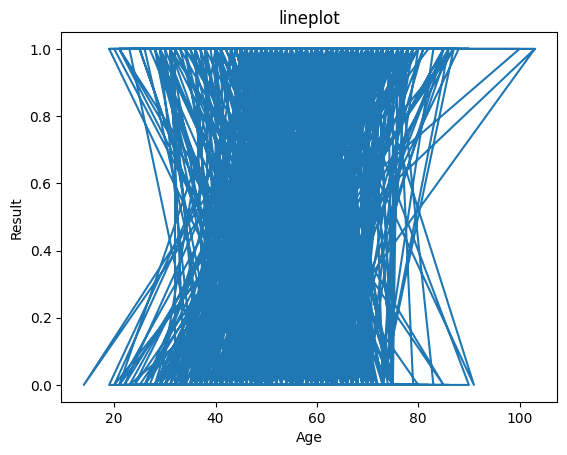

In [ ]:
plt.plot(df["Age"],df["Result"])
plt.title("lineplot")
plt.xlabel("Age")
plt.ylabel("Result")
plt.show()

<Axes: xlabel='Age', ylabel='Result'>

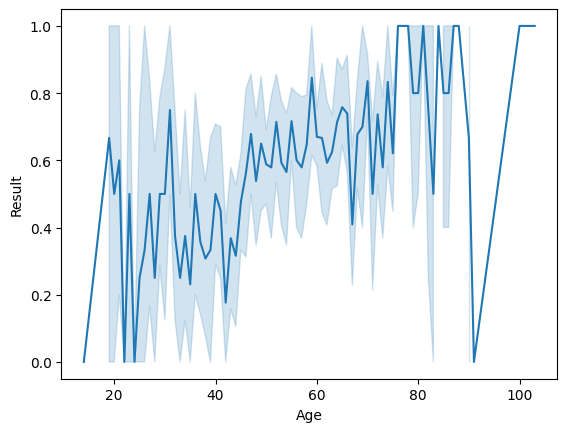

In [ ]:
sns.lineplot(x="Age",y="Result",data=df)

# Box plot

<Axes: xlabel='Age', ylabel='Result'>

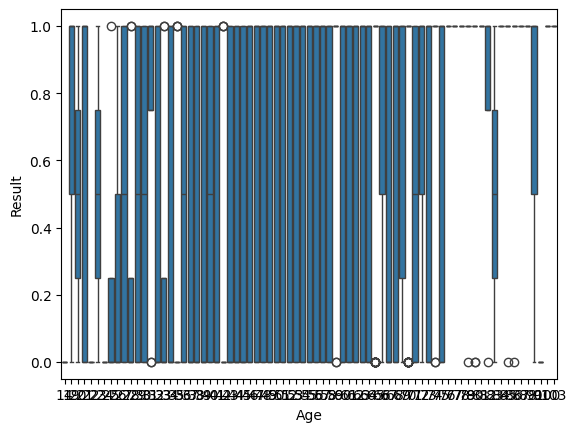

In [ ]:
sns.boxplot(x="Age",y="Result",data=df)

# Heatmap


<Axes: >

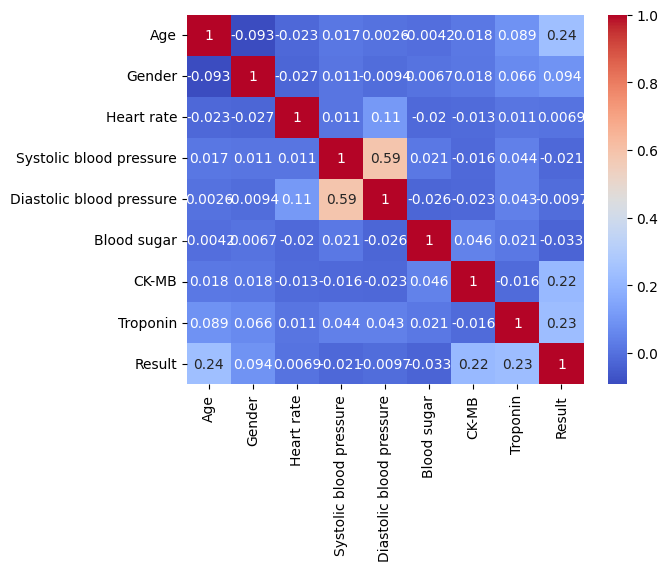

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")


# Model evaluation

In [ ]:
prediction_on_training_data = model.predict(x_train)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)
print(accuracy_on_training_data)

0.9886255924170616


In [ ]:
prediction_on_testing_data=model.predict(x_test)
accuracy_on_testing_data=accuracy_score(y_test,prediction_on_testing_data)
accuracy_on_testing_data

0.9848484848484849

#

In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

def predict_heart_attack(age, gender, heart_rate, systolic_bp, diastolic_bp, blood_sugar, ck_mb, troponin):

    input_data = pd.DataFrame([{
        'Age': age,
        'Gender': gender,
        'Heart rate': heart_rate,
        'Systolic blood pressure': systolic_bp,
        'Diastolic blood pressure': diastolic_bp,
        'Blood sugar': blood_sugar,
        'CK-MB': ck_mb,
        'Troponin': troponin
    }])


    scaled_input_data = sc.transform(input_data)


    prediction = model.predict(scaled_input_data)
    if prediction[0] == 1:
        return "Positive (High Risk of Heart Attack)"
    else:
        return "Negative (Low Risk of Heart Attack)"

In [ ]:

inputs = [
    gr.Slider(minimum=df['Age'].min(), maximum=df['Age'].max(), value=df['Age'].mean(), label='Age'),
    gr.Dropdown(choices=[0, 1], label='Gender (0=Female, 1=Male)', value=1),
    gr.Slider(minimum=df['Heart rate'].min(), maximum=df['Heart rate'].max(), value=df['Heart rate'].mean(), label='Heart Rate'),
    gr.Slider(minimum=df['Systolic blood pressure'].min(), maximum=df['Systolic blood pressure'].max(), value=df['Systolic blood pressure'].mean(), label='Systolic Blood Pressure'),
    gr.Slider(minimum=df['Diastolic blood pressure'].min(), maximum=df['Diastolic blood pressure'].max(), value=df['Diastolic blood pressure'].mean(), label='Diastolic Blood Pressure'),
    gr.Slider(minimum=df['Blood sugar'].min(), maximum=df['Blood sugar'].max(), value=df['Blood sugar'].mean(), label='Blood Sugar'),
    gr.Slider(minimum=df['CK-MB'].min(), maximum=df['CK-MB'].max(), value=df['CK-MB'].mean(), label='CK-MB Level'),
    gr.Slider(minimum=df['Troponin'].min(), maximum=df['Troponin'].max(), value=df['Troponin'].mean(), label='Troponin Level')
]


output = gr.Textbox(label='Prediction Result')

interface = gr.Interface(
    fn=predict_heart_attack,
    inputs=inputs,
    outputs=output,
    title="Heart Attack Prediction Model",
    description="Enter patient details to predict the risk of heart attack."
)

# Launch the interface
interface.launch(inline=True, share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>